# Uso del condicional `if`.




# Representación de Números Reales en Python

Los números que la computadora puede representar, en particular usando el lenguaje de Python, es limitada comparada con la cardinalidad del conjunto de números reales. Por ejemplo, la representación exacta del número  $\sqrt{2}$ requiere que almacenemos una cantidad infinita de números decimales, lo mismo que los números $\frac{1}{3}= 0.\bar{3}$, $\frac{1}{7}= 0.\overline{142857}$, etc.

El número de bits en donde la computadora almacena información, en particular un número real, es limitado y fijo para una computadora dada. Para poder almacenar el rango más grande posible de números dado un número fijo de bits, se utilizan números de  ***punto flotante***  (también llamados *flotantes*). En casi todas las plataformas en donde se utiliza Pyhton, los flotantes se almacenan con doble precisión (IEEE754), esto quiere decir que se designan un total de 64 bits para almacenar cada uno de ellos. Los números de punto flotante son una aproximación computacional a los números reales.

Un número flotante asigna una cantidad fija de bits a tres partes distintas de un número real:

1. El **signo**, llamado $s$, indica si es un número positivo o negativo, éste se almacena en 1 bit.
2. Un exponente o **característica**, llamado $e$, es una  potencia de 2, el cual se almacena en 11 bits.
3. La fracción o **mantisa** $f$ es el coeficiente del exponente y se almacena en 52 bits.

Con esta información, un número flotante se representa de la siguiente forma:

\begin{equation*}
n_f = (-1)^s2^{e-1023}\Big( 1+f\Big)
\end{equation*}

En Python, la información de un número flotante se obtiene usando el paquete `sys`.

In [ ]:
import sys
sys.float_info

sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)

## Convertir un número real en un número flotante

Convertir un número real a uno flotante (IEEE754) para su almacenamiento en la computadora consiste en determinar los elementos: signo ($s$), exponente ($e$) y fracción ($f$) para su represnetación en la forma expresada en la sección anterior. A continuación se describe, con un ejemplo, el algoritmo que permite determinar estos elementos:

*Cálculo de $s$, $e$ y $f$ para el número $5.75$.*

1. Determinar el signo.
* Si es número es positivo el bit que almacena el signo es 0.
* Si es número es negativo el bit es 1.

*El número $5.75$ es positivo por lo que $s=1$.*

2. Convertir el número a binario.
* Si el número tiene una parte entera, convertirla a binario.
* Si el número tiene una parte fraccionaria, multiplícarlo por 2 repetidamente y extraer el binario de la parte entera resultante (sólo puede ser 0 o 1) hasta conseguir la precisión deseada o hasta que el número se reduzca a cero.

*El número $5.75$ tiene como parte entera $5$ y parte farcccionaria  $0.75$.*
*El número $5$ en binario es: $101$*
*El número 0.75 se convierte a binario multiplicando por 2:*

$0.75 \times 2 = 1.5$

$0.5  \times 2 = 1.0$

*Por lo que el número $0.75$ en binario es $0.11$.*

**Conclusión:** *El número $5.75$ en binario es $101.11$*

3. Normalizar el número.
* Escribir el número en notación científica binaria:
$1.(mantisa) \times 2^{exponente}$.
* Mover el punto decimal de la representación binaria hasta que haya un solo bit 1 a la izquierda del punto. Contar cuántos lugares se movió el punto (ese es el exponente) y ajusta el número de bits después del punto (esa es la mantisa).

*El número $101.11$ se convierte en $1.0111\times 2^{2}$*

*Como el punto decimal se movió dos lugares, el exponente es $2$ y la mantisa es $0111$*

4. Calcular el exponente con sesgo.
* Puesto que el exponente se almacena en 11 bits, el sesgo es de 1023, esto quiere decir que el exponente que se almacena en binario está dado por:

$e = \textit{exponente real} + 1023$

*Convertir el exponente ajustado al sego en representación binaria de 11 bits.

* Si la representación binaria no ocupa 11 bits, se rellena con ceros.

*El exponente real del número $5.75$ es $2$, por lo que el exponente segado está dado por:*

$e= 2+1023=1025$

*El número $1025$ en binario es $10000000001$. Como ocupa 11 bits no es necesario completar con ceros.*

5. Obtener la fracción o mantisa.

* Tomar la parte fraccionaria de la representaciónn binaria normalizada, es decir lo que queda después del punto decimal y ajustar la mantisa para completar 52 bits. Si son menos, rellenar con ceros.

*La parte fraccionaria del número $5.75$ es $0111$ por lo que la mantisa con 52 bits es:*

$0111000000000000000000000000000000000000000000000000$

6. La representación final consiste de 64 bits distribuídos de la siguiente forma:

INSERTAR IMAGEN

*La representación del número 5.75 es:*

$$
\begin{aligned}
0 &  & 10000000001 & 0111000000000\\
  &  &             & 0000000000000\\
  &  &             & 0000000000000\\
  &  &             & 0000000000000
\end{aligned}
$$




Ejemplo:

Con el siguiente código se calcula la representación del número 5.75

In [ ]:
import struct

def mostrar_representacion_flotante(x):
    # Empaquetar el número como flotante de 64 bits
    packed_x = struct.pack('>d', x)
    # Convertir a un entero de 64 bits para ver los bits
    int_rep = int.from_bytes(packed_x, byteorder='big')
    # Convertir a binario
    binario_flotante = bin(int_rep)[2:].zfill(64)
    return binario_flotante

numero_real = float(input("Ingresa un número real en su expresión decimal: "))
binario_flotante = mostrar_representacion_flotante(numero_real)
print(f"El número {numero_real} en binario (IEEE 754, 64 bits) es:\n{binario_flotante}")

Ingresa un número real en su expresión decimal: 0.1
El número 0.1 en binario (IEEE 754, 64 bits) es:
0011111110111001100110011001100110011001100110011001100110011010


## Operaciones con flotantes.

Podemos realizar las siguientes operaciones aritméticas con Python

1. Suma
2. Resta
3. Multiplicación
4. División
5. Potencias(reales)

El siguiente código pide al usuario dos números reales, los almacena como un flotante y realiza las operaciones de suma, resta, multiplicación, división y los eleva a una potencia.

In [ ]:
from __future__ import division

#Entrada de dos números reales
numero_1 = float(input("Ingresa un número real: " ))
numero_2 = float(input("Ingresa otro número real: " ))

#Suma de los números
suma = numero_1+numero_2

#Resta de los números
resta = numero_1-numero_2

#Producto de dos números
multiplicacion = numero_1*numero_2

#División de dos números
division =  numero_1/numero_2

#Potencia
potencia = pow(numero_1,numero_2)

#Impresión de resultados de las operaciones
print(f"El resultado de la suma:  {numero_1} + {numero_2} = {suma}")
print(f"El resultado de la resta:  {numero_1} - {numero_2} = {resta}")
print(f"El resultado de la multipliación:  {numero_1} * {numero_2} = {multiplicacion}")
print(f"El resultado de la división:  {numero_1} / {numero_2} = {division}")
print(f"El resultado de la potencia:  {numero_1} ^ {numero_2} = {potencia}")

Ingresa un número real: 1.4
Ingresa otro número real: 2.4
El resultado de la suma:  1.4 + 2.4 = 3.8
El resultado de la resta:  1.4 - 2.4 = -1.0
El resultado de la multipliación:  1.4 * 2.4 = 3.36
El resultado de la división:  1.4 / 2.4 = 0.5833333333333334
El resultado de la potencia:  1.4 ^ 2.4 = 2.2423700574830967


## Práctica 1.1. Uso de Números de Punto Flotante en Python.

**Objetivo:** Que el estudiante comprenda cómo los números reales se operan en Python, cómo se representan, almacenan y los errores que pueden surgir debido a las limitaciones de la representación de números flotantes en binario.

Un ejemplo clásico de errores que surgen por la rerpesentación de números reales en el estándar IEEE754 es la representación de los números $0.1$ y el número $0.2$, entre otros.

**Actividades**

1. De acuerdo al algoritmo presentado, obtén la representación de los números: $1.5$, $2.3$, $4.5$, $3.0$, $0.1$ y $0.2$ en el formato de punto flotante. Observa que algunos de estos números no pueden ser representados de forma exacta con $64$ bits.

2. Utiliza el programa proporcionado que emplea el módulo `struct` para comparar tu resultado.

3. Escribe una celda de código en donde se realicen las siguientes operaciones:

$0.1+0.2$

$1.5-1.1$

$2.3\times 4.5$

De acuerdo a la aritmética tradicional, ¿Por qué ocurren errores en las operaciones realizadas con Python?

4. El siguiente código compara dos números flotantes, modifícalo y ejecútalo para comparar el resultado aritmético de las operaciones realizadas en el ejercicio 3 con el resultado numérico de dichas operaciones con Python.

In [ ]:
# Actividad 2
import struct

def calculo_representacion_flotante(x):
    # Empaquetar el número como flotante de 64 bits
    packed_x = struct.pack('>d', x)
    # Convertir a un entero de 64 bits para ver los bits
    int_rep = int.from_bytes(packed_x, byteorder='big')
    # Convertir a binario
    binario_flotante = bin(int_rep)[2:].zfill(64)
    return binario_flotante

numero_real = float(input("Ingresa un número real en su expresión decimal: "))
binario_flotante = calculo_representacion_flotante(numero_real)
print(f"El número {numero_real} en binario (IEEE 754, 64 bits) es:\n{binario_flotante}")

Ingresa un número real en su expresión decimal: 0.1
El número 0.1 en binario (IEEE 754, 64 bits) es:
0011111110111001100110011001100110011001100110011001100110011010


In [ ]:
#Actividad 3
a = 0.1
b = 0.2
print(f"La suma de {a}+{b} es igual a {a+b}")
c = 1.5
d = 1.1
print(f"La resta de {c} menos {d} es igual a {c-d}")
e = 2.3
f = 4.5
print(f"El producto de {e} por {f} es igual a {e*f}")

La suma de 0.1+0.2 es igual a 0.30000000000000004
La resta de 1.5 menos 1.1 es igual a 0.3999999999999999
El producto de 2.3 por 4.5 es igual a 10.35


In [ ]:
# Actividad 4
resultado_numerico_1 = 0.1+0.2
resultado_aritmético_1 = 0.3
if resultado_numerico_1 == resultado_aritmético_1:
  print(f"{resultado_aritmético_1} es igual a {resultado_numerico_1}")
else:
  print(f"{resultado_aritmético_1} no es igual a {resultado_numerico_1}")

resultado_numerico_2 = 1.5-1.1
resultado_aritmético_2 = 0.4
if resultado_numerico_2 == resultado_aritmético_2:
  print(f"{resultado_aritmético_2} es igual a {resultado_numerico_2}")
else:
  print(f"{resultado_aritmético_2} no es igual a {resultado_numerico_2}")

resultado_numerico_3 = 2.3*4.5
resultado_aritmético_3 = 10.35
if resultado_numerico_3 == resultado_aritmético_3:
  print(f"{resultado_aritmético_3} es igual a {resultado_numerico_3}")
else:
  print(f"{resultado_aritmético_3} no es igual a {resultado_numerico_3}")


0.3 no es igual a 0.30000000000000004
0.4 no es igual a 0.3999999999999999
10.35 es igual a 10.35


## Propiedades de campo de los números reales

Los números reales cumplen con las siguientes propiedades de campo :

* **Cerradura** de la suma y del producto:

$a+b \in \mathbb{R}$

$a\cdot b \in \mathbb{R}$

* **Conmutatividad** de la suma y del producto:

$a+b = b+a$

$a\cdot b =b \cdot a$

* **Asociatividad** de la  suma y del producto:

Para cualesquiera tres números $a$, $b$, $c$ $\in \mathbb{R}$,

$(a+b) + c = a+(b+c)$

$(a\cdot b) \cdot c = a \cdot (b \cdot c)$

* **Existencia del número inverso** para la operación de suma y para la operación de producto, los cuales se obtienen como:

Para cualquier número $a \in {\mathbb R}$, $-a$ es el inverso de la suma

Para cualquier número $a \in {\mathbb R}$ distinto de $0$, $\frac{1}{a}$ es el inverso del producto.

* **Existencia de un número neutro** para la suma y un número neutro para el producto, en el caso de la suma el neutro es $0$ y en el caso del producto el neutro es $1$, éstos cumplen que:

Para cualquier número $a \in {\mathbb R}$, $a+0=a$

Para cualquier número $a \in {\mathbb R}$, $a*1=a$

* **Distributividad** de la operaciones de suma y producto.

Para cualesquiera tres números $a$, $b$, $c$ $\in \mathbb{R}$, $a\cdot(b+c)=a\cdot b + a\cdot b$


## Práctica 1.2. ¿Los números flotantes son un campo?

**Objetivo:** Que el estudiante comprenda las propiedades de campo que cumplen los números reales y cuáles sí y cuáles no cumplen los números de punto flotante en Python.


**Actividad**

Utiliza los códigos de Python que te permitan responder las siguientes preguntas:

1. ¿La propiedad de cerradura en la suma y el producto se cumple para cualesquiera dos números flotantes?

2. ¿La propiedad de conmutatividad en la suma y el producto se cumpln para cualesquiera dos números flotantes?

3. ¿La propiedad de asociatividad en la suma y el producto se cumple en los números flotantes?

4. ¿Para cada número flotante existen los neutros en la suma y el producto,  y son números flotantes?

5. ¿Para cada número flotante existen los inversos en la suma y el producto, y son números flotantes?

6. ¿Para cualesquiera tres números flotantes se cumple la propiedad de distributividad?

In [ ]:
#Actividad cero
import struct

def calculo_representacion_flotante(x):
    # Empaquetar el número como flotante de 64 bits
    packed_x = struct.pack('>d', x)
    # Convertir a un entero de 64 bits para ver los bits
    int_rep = int.from_bytes(packed_x, byteorder='big')
    # Convertir a binario
    binario_flotante = bin(int_rep)[2:].zfill(64)
    return binario_flotante

numero_real = float(input("Ingresa un número real en su expresión decimal: "))
binario_flotante = calculo_representacion_flotante(numero_real)
print(f"El número {numero_real} en binario (IEEE 754, 64 bits) es:\n{binario_flotante}")

In [ ]:
# Actividad 1
a = float(input("Ingresa un número real a en expresión decimal b: "))
b = float(input("Ingresa un número real b en expresión decimal a: "))
suma = a+b
producto = a*b

a_f = calculo_representacion_flotante(a)
b_f = calculo_representacion_flotante(b)
suma_f = calculo_representacion_flotante(suma)
producto_f =calculo_representacion_flotante(producto)

print(type(suma))
print(type(producto))


if a_f+b_f == suma_f:
  print("La suma de números flotantes es un número flotante")
else:
  print("La suma de números flotantes no es un número flotante")

if a_f*b_f == producto_f:
  print("La suma de números flotantes es un número flotante")
else:
  print("La suma de números flotantes no es un número flotante")


In [ ]:
# Actividad 2
a = float(input("Ingresa un número real a en expresión decimal a: "))
b = float(input("Ingresa un número real b en expresión decimal b: "))

if a+b == b+a:
  print("La suma de dos números flotantes es conmutativa")
else:
  print("La suma de dos números flotantes NO es conmutativa")

if a*b == b*a:
  print("El producto de dos números flotantes es conmutativo")
else:
  print("El producto de dos números flotantes NO es conmutativo")

Ingresa un número real a en expresión decimal a: 1
Ingresa un número real b en expresión decimal b: 6
La suma de dos números flotantes es conmutativa
El producto de dos números flotantes es conmutativo


In [ ]:
# Actividad 3
a = float(input("Ingresa un número real a en expresión decimal a: "))
b = float(input("Ingresa un número real b en expresión decimal b: "))
c = float(input("Ingresa un número real c en expresión decimal c: "))
suma = a+(b+c)
producto = (a*b)*c

if a+(b+c) == (a+b)+c:
  print("La suma de tres números flotantes es asociativa")
else:
  print("La suma de tres números flotantes NO es asociativa")

if (a*b)*c== a*(b*c):
  print("El producto de tres números flotantes es asociativa")
else:
  print("El producto de tres números flotantes NO es asociativo")

Ingresa un número real a en expresión decimal a: 1
Ingresa un número real b en expresión decimal b: 3
Ingresa un número real c en expresión decimal c: 7
La suma de tres números flotantes es asociativa
El producto de tres números flotantes es asociativa


In [ ]:
# Actividad 4
a = float(input("Ingresa un número real a en expresión decimal a: "))
b = float(input("Ingresa un número real b distinto de cero en expresión decimal b: "))

inverso_suma = -a
print(inverso_suma)
reciproco_producto = 1/b
print(b*reciproco_producto)

if a+inverso_suma == 0:
  print(f"El inverso del número {a} es un número flotante")
else:
  print(f"El inverso del número {a} NO es un número flotante")

if b*reciproco_producto == 1:
  print(f"El recíproco del número {b} es un número flotante")
else:
  print(f"El recíproco del número {b} NO es un número flotante")



Ingresa un número real a en expresión decimal a: 4
Ingresa un número real b distinto de cero en expresión decimal b: 3
-4.0
1.0
El inverso del número 4.0 es un número flotante
El recíproco del número 3.0 es un número flotante


In [ ]:
# Actividad 5
a = float(input("Ingresa un número real a en expresión decimal a: "))
b = float(input("Ingresa un número real b en expresión decimal b: "))

if a+0 == a:
  print(f"El neutro de la suma es un número flotante")
else:
  print(f"El neutro de la suma NO es un número flotante")

if b*1 == b:
  print(f"El neutro de la suma es un número flotante")
else:
  print(f"El neutro de la suma NO es un número flotante")


Ingresa un número real a en expresión decimal a: 2.3
Ingresa un número real b en expresión decimal b: 5.0
El neutro de la suma es un número flotante
El neutro de la suma es un número flotante


In [ ]:
# Actividad 6
a = float(input("Ingresa un número real a en expresión decimal a: "))
b = float(input("Ingresa un número real b en expresión decimal b: "))
c = float(input("Ingresa un número real b en expresión decimal c: "))

if a*(b+c) == (a*b)+(a*c):
  print(f"Los números flotantes cumplen la propiedad distributiva")
else:
  print(f"Los números flotantes NO cumplen la propiedad distributiva")

Ingresa un número real a en expresión decimal a: 3.4
Ingresa un número real b en expresión decimal b: 5.6
Ingresa un número real b en expresión decimal c: 1.2
Los números flotantes cumplen la propiedad distributiva


## Propiedades de orden de los número reales.

Los números reales cumplen con las siguientes propiedades de orden:

Para cuales quiera dos números reales, $a$ y $b$ se sólo se cumple cualquiera de las tres afirmaciones siguientes:

$a<b$, $a>b$, ó $a=b$

Python puede determinar el ordeon de dos números reales, es decir, determinar el valor de verdad de afirmaciones que involucren propiedades de orden. En la siguiente de celde de código se comparan dos números:

In [ ]:
a = float(input("Introduce un número real a: "))
b = float(input("Introduce un número real b: "))

a<b

Introduce un número real a: 3
Introduce un número real b: 6


True

Dado el valor de verdad de una afirmación, podemos hacer un código usando la estructura de `if` que comparE dos números reales:


In [ ]:
a = float(input("Introduce un número real a: "))
b = float(input("Introduce un número real b: "))

if a<b:
  print(f"El número {a} es menor que {b}")
elif a<b:
  print(f"El número {a} es mayor que {b}")
else:
  print(f"El número {a} es igual que {b}")

Introduce un número real a: 1.2
Introduce un número real b: 1.2
El número 1.2 es igual que 1.2


## Valor absoluto
El valor absoluto de un número real es siempre un número positivo que geométricamente nos da la distancia de dicho número real al origen, se define como:

$
|x| = \left\{
  \begin{array}{lcc}
  -x & si & x < 0 \\
  x & si & x\geq 0 \\
      \end{array} \right.
$

Para calcular el valor absoluto de un un número real, ocupamos la función `abs()`. El siguiente código evalúa el valor absoluto de un núemero real.

In [ ]:
numero_real = float(input("Ingresa un número real: "))

valor_absoluto = abs(numero_real)

print(f"El valor absoluto del número real {numero_real} es: {valor_absoluto}")

Ingresa un número real: -4.7
El valor absoluto del número real -4.7 es: 4.7


## Valor absoluto de la diferencia de dos números reales.

Dados dos números reales, $a$ y $b$, ocurre que

$
|a-b|=|b-a|
$
 y además, $|a-b|$ resulta ser igual a la distancia en la recta real que hay entre los números $a$ y $b$.

 El siguiente código permite graficar dos números en la recta real y calcular el valor absluto de la diferencia entre éstos. Observa que el valor absoluto de la resta es precisamente la distancia entre ambos números.


Escribe un número a: -3
Escribe un número b: -6


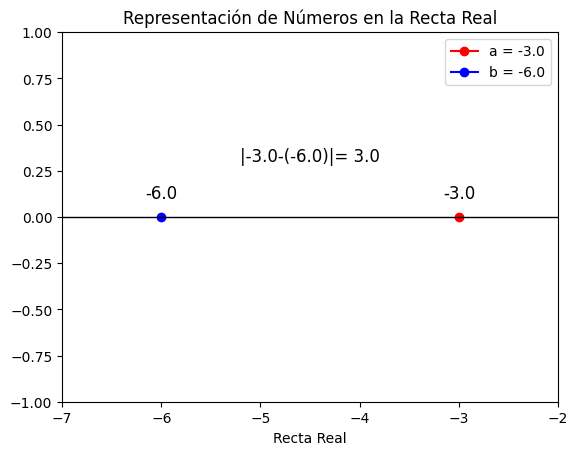

In [ ]:
import matplotlib.pyplot as plt

def graficar_numeros_en_recta_real(a, b):
    # Crear una figura y un eje
    fig, ax = plt.subplots()

    # Graficar los números en la recta real
    ax.plot([a], [0], "r-o", label=f'a = {a}')
    ax.plot([b], [0], 'b-o', label=f'b = {b}')

    # Configuración de la recta real
    ax.axhline(0, color='black', lw=1)
    ax.set_ylim([-1, 1])
    ax.set_xlabel('Recta Real')

    # Etiquetas para los números
    ax.text(a, 0.1, f'{a}', fontsize=12, ha='center')
    ax.text(b, 0.1, f'{b}', fontsize=12, ha='center')

    # Distancia: |a-b|
    ax.text((a+b)/2, 0.3, f'|{a}-({b})|= {abs(a-b)}', fontsize=12, ha='center')

    # Rango de la gráfica en el eje x
    plt.xlim(min(a, b) - 1, max(a, b) + 1)

    # Título y leyenda
    plt.title('Representación de Números en la Recta Real')
    plt.legend()

    # Mostrar la gráfica
    plt.show()

# Ingresar los números directamente en lugar de utilizar input()
a = float(input("Escribe un número a: "))
b = float(input("Escribe un número b: "))

graficar_numeros_en_recta_real(a, b)

## Práctica 1.3. Distancia entre dos números reales.

**Objetivo:** Que el estudiante comprenda las propiedades de campo que cumplen los números reales y cuáles sí y cuáles no cumplen los números de punto flotante en Python.


**Actividad**

Utiliza los códigos de Python que te permitan responder las siguientes preguntas:

1. ¿La propiedad de cerradura en la suma y el producto se cumple para cualesquiera dos números flotantes?

2. ¿La propiedad de conmutatividad en la suma y el producto se cumpln para cualesquiera dos números flotantes?

3. ¿La propiedad de asociatividad en la suma y el producto se cumple en los números flotantes?

4. ¿Para cada número flotante existen los neutros en la suma y el producto,  y son números flotantes?

5. ¿Para cada número flotante existen los inversos en la suma y el producto, y son números flotantes?

6. ¿Para cualesquiera tres números flotantes se cumple la propiedad de distributividad?


# Funciones en Python.

Una función de variable real es una relación entre dos conjuntos, en la cual a cada número real (del dominio de la función) se le asigna exactamente un número real (del codominio). Formalmente, una función de variable real se puede expresar como:

$f: \mathbb D \subset \mathbb R \longmapsto \mathbb  R$

Donde $\mathbb D$ es un subconjunto de los números reales y la función f asigna a cada número real $x$ del conjunto $\mathbb D$ a un solo valor real, denominado $f(x)$.

Es muy importante recorda que las funciones de variale real se expresan algebraicamente por medio una fórmula, la cual expresa la regla de correspondencia.

La representación gráfica de funiciones es muy importante y en Python esto se realiza



#El uso del ciclo `for`.

El ciclo `for` en python se utiliza para hacer una iteración sobre una secuencia de elementos, los cuales pueden ser una lista, una tupla, un diccionario, un conjunto o una cadena de texto. Se utiliza en programación para ejecutar líneas de código de forma repetida, una por nada elemento de la lista.

La sintáxis es la siguiente:

```
for variable in secuencia:
  #Lineas de código a ejecutar
```


*   La palabra `for` es la palabra que indica el inicio del ciclio de iteración.
*   La palabra `variable` es el nombre de la variable que tomará el valor de cada uno de los elementos de la secuencia en cada iteración. Puede ser nombrada de cualquier forma pero lo recomendable es que se le asigne un nombre que denote el tipo de datos sobre los que se está iterando.
*   La palabra `in` indica que la variable tomará el valor de cada elemento en la secuencia.
*   La palabra `secuencia` es la estructura de datos sobre la que se va a iterar. Puede ser uan lista, una tupla, etc.
*  `:` (dos puntos) indican el final de la declaración del ciclo y el inicio de las líneas que se ejecutarán.
*   `Líneas de código a ejecutar` es el conjunto de líneas de código que se ejecutarán de forma repetida, una vez por cada elemento de la secuencia.  Es importante notar que estas líneas de código deben estar escritas de forma identada, con un número fijo de espacio o un tabulador.

Veamos algunos ejemplos.

##Ejemplos de uso:

###1. Iterar sobre una lista.

En el siguiente código se ha declado la lista

```
colores=['azul', 'amarillo', 'rojo', 'verde', 'anaranjado', 'rosa']
```

Ejecuta la celda de código y observa qué ocurre.

In [ ]:
colores=['azul', 'amarillo', 'rojo', 'verde', 'anaranjado', 'rosa']
for color in colores:
  print(color)

azul
amarillo
rojo
verde
anaranjado
rosa


### 2. Iterar sobre una lista de números.

En el siguiente código se ha declarado la lista

```
numeros=[2,3,4,5,6,8,10]
```

Ejecuta la celda de código y observa qué ocurre.

In [ ]:
numeros=[2,3,4,5,6,8,10]
for numero in numeros:
  numero_par=2*numero
  print(numero_par)

4
6
8
10
12
16
20


### 3. Ejecutar código repetidamente.

Si sólo se desea ejecutar líneas de código de forma repetida, podemos usar
```
range(n,m,paso)
```
* `n` es el número donde comienza la secuencia. Si no se especifica, comienza en $0$.
* `m` es el número que indica que termina la secuencia y no se incluye, es decir, la secuancia termina en $n-1$.
* `paso` es el incremento entre cada número de la secuencia.

Ejecuta las siguientes celdas de código y observa qué ocurre.

In [ ]:
for n in range(10):
  print(n)

0
1
2
3
4
5
6
7
8
9


In [ ]:
for n in range(1,10):
  print("5 x",n,"=",5*n)

5 x 1 = 5
5 x 2 = 10
5 x 3 = 15
5 x 4 = 20
5 x 5 = 25
5 x 6 = 30
5 x 7 = 35
5 x 8 = 40
5 x 9 = 45


In [ ]:
for n in range(1,20,3):
  print("Hola", n)

Hola 1
Hola 4
Hola 7
Hola 10
Hola 13
Hola 16
Hola 19


### 4. Iterar sobre una cadena de texto

En el siguiente código se ha declarado una cadena de caracteres:

```
cadena="HolaMundo"
```
Ejecuta la celda de código y observa qué ocurre.




In [ ]:
cadena="HolaMundo"
for letra in cadena:
  print(letra)

H
o
l
a
M
u
n
d
o


### 5. Sumar números de una lista

En el siguiente código se ha declarado la lista de números:

```
lista_numeros=[3,5,7,9,11,13,15]
```
se ha declarado la variable suma, con valor 0

```
suma=0
```

Ejecuta el siguiente código y observa cómo con el ciclo `for` podemos sumar los números en la lista.


In [ ]:
lista_numeros=[3,5,7,9,11,13,15]
suma=0
for n in lista_numeros:
  suma = suma+n #se puede abreviar suma=+n
print(suma)

63


# Sucesiones

Una sucesión $S_n$ es una función cuyo dominio es el conjunto de números naturales  $\mathbb{N}$ y el contradominio es el conjunto de números reales $\mathbb R$:
\begin{equation*}
S_n: \mathbb N \longmapsto \mathbb D \subset R
\end{equation*}

$$
\begin{equation*}
S_n=f(n)
\end{equation*}
$$

Por ejemplo:

\begin{aligned}
S_n      & = \frac{1}{n}\\
\alpha_n & = n\\
\beta_n  & = (-1)^{n}\\
\gamma_n & = 2n
\end{aligned}





##Cálculo de los términos de una sucesión.

Para calcular los términos de una sucesión podemos utilizar el ciclo `for`.

En la siguiente celda de código se calculan los términos se la sucesión $S_n=\frac{1}{n}$ para valores de $n\leq20$

In [ ]:
for n in range(1,21):
  Sn=1/n
  print("Para",n,"el valor de Sn=1/n es:",Sn)

Para 1 el valor de Sn=1/n es: 1.0
Para 2 el valor de Sn=1/n es: 0.5
Para 3 el valor de Sn=1/n es: 0.3333333333333333
Para 4 el valor de Sn=1/n es: 0.25
Para 5 el valor de Sn=1/n es: 0.2
Para 6 el valor de Sn=1/n es: 0.16666666666666666
Para 7 el valor de Sn=1/n es: 0.14285714285714285
Para 8 el valor de Sn=1/n es: 0.125
Para 9 el valor de Sn=1/n es: 0.1111111111111111
Para 10 el valor de Sn=1/n es: 0.1
Para 11 el valor de Sn=1/n es: 0.09090909090909091
Para 12 el valor de Sn=1/n es: 0.08333333333333333
Para 13 el valor de Sn=1/n es: 0.07692307692307693
Para 14 el valor de Sn=1/n es: 0.07142857142857142
Para 15 el valor de Sn=1/n es: 0.06666666666666667
Para 16 el valor de Sn=1/n es: 0.0625
Para 17 el valor de Sn=1/n es: 0.058823529411764705
Para 18 el valor de Sn=1/n es: 0.05555555555555555
Para 19 el valor de Sn=1/n es: 0.05263157894736842
Para 20 el valor de Sn=1/n es: 0.05


### Ejercicios

Escribe códigos que evalúen los términos de las siguientes sucesiones:

1. $\displaystyle \alpha_n =1+\frac{1}{n}$, con $n\leq10$
2. $\displaystyle \beta_n  = (-1)^n$, con $n\leq10$
3. $\displaystyle \gamma_n = \sin\Big(13+\frac{1}{n^2}\Big)$, con $n\leq10$
4. $\displaystyle \delta_n=\frac{1}{n^2}$, con $n\leq10$
5. $\displaystyle \theta_n=\frac{n}{n+1}$, con $n\leq15$
6. $\displaystyle S_n=\frac{n+3}{n^3+4}$, con $n\leq25$
7. $\displaystyle R_n=\frac{n!}{n^n}$, con $n\leq10$
8. $\displaystyle M_n=\frac{2n}{3n^2+2n+1}$, con $n\leq20$
9. $\displaystyle Q_n=3n^n$, con $n\leq20$
10. $\displaystyle W_n=\frac{3^n+(-1)^n}{3^{n+1}+(-1)^{n+1}}$, con $n\leq20$




## Gráficas de Sucesiones
Al igual que para una función, podemos trazar la gráfica de una suceción.

En el siguiente ejemplo se calculan los términos de la sucesión $S_n=\frac{1}{n}$, con $n \leq 20$ y se grafica la función.

[1.0, 0.5, 0.3333333333333333, 0.25, 0.2, 0.16666666666666666, 0.14285714285714285, 0.125, 0.1111111111111111, 0.1, 0.09090909090909091, 0.08333333333333333, 0.07692307692307693, 0.07142857142857142, 0.06666666666666667, 0.0625, 0.058823529411764705, 0.05555555555555555, 0.05263157894736842, 0.05]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


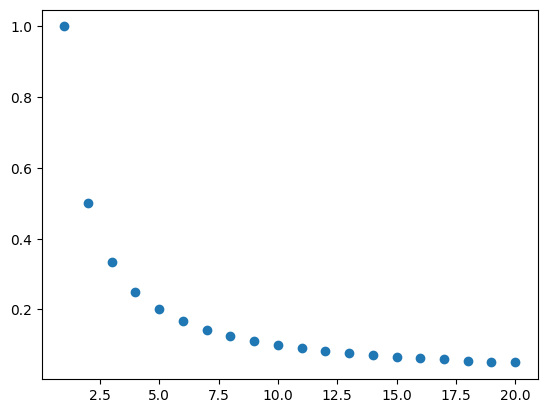

In [ ]:
from pylab import *

# Declaración de las listas donde se almacenarán los valores de la Sucesión
Sn=[]
n =[]

# Ciclo for para el cáculo de cada término k desde 1 hasta 20
for k in range(1,21):
  Sn.append(1/k)
  n.append(k)

print(Sn)
print(n)
scatter(n,Sn)

### Ejercicios

Escribe el código que calcule y grafique cada una de las siguientes sucesiones:

1. $\displaystyle \alpha_n =1+\frac{1}{n}$, con $n\leq10$
2. $\displaystyle \beta_n  = (-1)^n$, con $n\leq10$
3. $\displaystyle \gamma_n = \sin\Big(13+\frac{1}{n^2}\Big)$, con $n\leq10$
4. $\displaystyle \delta_n=\frac{1}{n^2}$, con $n\leq10$
5. $\displaystyle \theta_n=\frac{n}{n+1}$, con $n\leq15$
6. $\displaystyle S_n=\frac{n+3}{n^3+4}$, con $n\leq25$
7. $\displaystyle R_n=\frac{n!}{n^n}$, con $n\leq10$
8. $\displaystyle M_n=\frac{2n}{3n^2+2n+1}$, con $n\leq20$
9. $\displaystyle Q_n=3n^n$, con $n\leq20$
10. $\displaystyle W_n=\frac{3^n+(-1)^n}{3^{n+1}+(-1)^{n+1}}$, con $n\leq20$

## Límite de una sucesión

Una sucesión $S_n$ converge hacia el número $L$, y escribimos:

\begin{equation}
\displaystyle \lim_{n \to \infty}{S_n}=L
\end{equation}

Si ocurre que para cualquier valor razonablemente pequeño $\epsilon >0$ existe un número natural $N$ tal que para todos los términos $S_n$ que siguen (es decir, se cumple que $n>N$) ocurre que

\begin{equation}
\displaystyle |S_n-L|<\epsilon
\end{equation}

##Práctica 3.1.

**Objetivo:** Que el estudiante identifique el concepto de límite mediante el cálculo de los términos de una sucesión y su gráfica. Que el estudiante reconozca y analice la definición de límite de una sucesión de Cauchy a através del cálculo del término $S_n$ de la sucesión que cumple con la condición $|S_n-L|<\epsilon$ para cualquier valor de $\epsilon$ pequeño.  

**Actividades.**

1. Obtén los primeros 15 términos de la sucesión

\begin{equation}
\displaystyle S_n= 1-\frac{1}{n}
\end{equation}


2. Obtén de la suceción usando los puntos calculados. De acuerdo a la gráfica, ¿a qué valor se acercan los términos de la sucesión con el incremento de $n$?, es decir, ¿cuál dirías que es el límite $L$ de la sucesión?

3. Dado el valor de $\epsilon=1\times 10^{-2}$, calcula tantos términos de la sucesión $S_n$ como necesites para encontrar el que cumpla que
\begin{equation}
\displaystyle |S_n-L|<\epsilon
\end{equation}

4. Escribe un código que imprima únicamente el término $S_n$ que cumple la condición anterior.

5. Toma valores más pequeños de $\epsilon$, a saber, $1\times 10^{-3}$,  $1\times 10^{-4}$ y $1\times 10^{-6}$ y halla el término Sn que cumple la condición $|S_n-L|<\epsilon$ en cada caso.



In [ ]:
from pylab import *
# Actividad 1
def Sucesion_1(x):
  return 1-(1/x)

for i in range(1,16):
  print(i, Sucesion_1(i))

In [ ]:
# Actividad 2
n  = []
Sn = []
for i in range(1,16):
  n.append(i)
  Sn.append(Sucesion_1(i))
print(n)
print(Sn)

scatter(n, Sn)

In [ ]:
# Actividad 3
L = 1
epsilon = 1e-2

for i in range(1,120):
  print(f"El término {i} de la sucesión es {Sucesion_1(i)}, |{Sucesion_1(i)}-{L}|={abs(Sucesion_1(i)-L)}")

In [ ]:
# Actividad 4
L = 1
epsilon = 1e-2

for i in range(1,120):
  if abs(Sucesion_1(i)-L)< epsilon:
    print(f"El término {i} de la sucesión es {Sucesion_1(i)}, |{Sucesion_1(i)}-{L}|={abs(Sucesion_1(i)-L)}")
    break

In [ ]:
# Actividad 5
L = 1
epsilon1 = 1e-3
epsilon2 = 1e-4
epsilon3 =1e-6

for i in range(1,10000000000):
  if abs(Sucesion_1(i)-L)< epsilon3:
    print(f"El término {i} de la sucesión es {Sucesion_1(i)}, |{Sucesion_1(i)}-{L}|={abs(Sucesion_1(i)-L)}")
    break

## Práctica 3.2

**Actividades.**

Para las siguientes sucesiones:

a) $\displaystyle S_n =$

\begin{equation}
\displaystyle S_n= 1-\frac{1}{n}
\end{equation}


2. Obtén la gráfica de dichos puntos. De acuerdo a la gráfica, ¿a qué valor se acercan los términos de la sucesión con el incremento de $n$?, es decir, ¿cuál dirías que es el límite $L$ de la sucesión?.

3. Dado el valor de $\epsilon=1\times 10^{-2}$, calcula tantos términos de la sucesión $S_n$ como necesites para encontrar el que cumpla que
\begin{equation}
\displaystyle |S_n-L|<\epsilon
\end{equation}

4. Escribe un código que imprima únicamente el término $S_n$ que cumple la condición anterior.

5. Toma valores más pequeños de $\epsilon$, a saber, $1\times 10^{-3}$,  $1\times 10^{-4}$ y $1\times 10^{-6}$ y halla el término Sn que cumple la condición $|S_n-L|<\epsilon$ en cada caso.
